## Phase 1 — Environment Setup & Data Loading

### 1.1 — Import Libraries

In [1]:
# ── Core ─────────────────────────────────────────────────────────────────────
import warnings
import os
from pathlib import Path

warnings.filterwarnings("ignore")

# ── Data ─────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import (
    LabelEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
)
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# ── Gradient Boosting ─────────────────────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# ── Hyperparameter Optimisation ───────────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)   # suppress per-trial noise

# ── SHAP (Model Explainability) ───────────────────────────────────────────────
import shap

# ── Display config ────────────────────────────────────────────────────────────
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✅ Libraries imported successfully")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   xgboost {xgb.__version__}")
print(f"   lightgbm {lgb.__version__}")
print(f"   optuna  {optuna.__version__}")
print(f"   shap    {shap.__version__}")

✅ Libraries imported successfully
   pandas  2.2.3
   numpy   2.1.3
   xgboost 3.2.0
   lightgbm 4.6.0
   optuna  4.9.0
   shap    0.52.0


### 1.2 — File Paths

In [2]:
# ── Resolve paths relative to this notebook ───────────────────────────────────
ROOT = Path(".")                                      # SpotterAssignment/
DATA = ROOT / "data"

TRAIN_PATH       = DATA / "train-test.csv"
VALIDATION_PATH  = DATA / "validation.csv"
DECEMBER_PATH    = DATA / "december-chart-inputs.csv"
TEMPLATE_PATH    = DATA / "validation-predictions-template.csv"

OUTPUT_PREDICTIONS = ROOT / "validation_predictions.csv"  # final submission file

# ── Verify every input file exists ────────────────────────────────────────────
all_paths = {
    "train-test.csv": TRAIN_PATH,
    "validation.csv": VALIDATION_PATH,
    "december-chart-inputs.csv": DECEMBER_PATH,
    "validation-predictions-template.csv": TEMPLATE_PATH,
}

print("File existence check:")
all_ok = True
for name, path in all_paths.items():
    exists = path.is_file()
    size_mb = path.stat().st_size / 1e6 if exists else 0
    status = "Present" if exists else "Missing"
    print(f"   {status}  {name:<45}  {size_mb:.2f} MB")
    if not exists:
        all_ok = False

if all_ok:
    print("All input files present.")
else:
    raise FileNotFoundError("One or more required input files are missing. Check the paths above.")

File existence check:
   Present  train-test.csv                                 5.96 MB
   Present  validation.csv                                 1.39 MB
   Present  december-chart-inputs.csv                      0.00 MB
   Present  validation-predictions-template.csv            0.13 MB
All input files present.


### 1.3 — Load CSVs & Parse Dates

In [3]:
# ── Load all datasets ─────────────────────────────────────────────────────────
df_train    = pd.read_csv(TRAIN_PATH,      parse_dates=["date"])
df_val      = pd.read_csv(VALIDATION_PATH, parse_dates=["date"])
df_dec      = pd.read_csv(DECEMBER_PATH,   parse_dates=["date"])
df_template = pd.read_csv(TEMPLATE_PATH)

print("All CSVs loaded.")

All CSVs loaded.


### 1.4 — Sanity Checks

In [4]:

def dataset_summary(df: pd.DataFrame, name: str) -> None:
    print("=" * 72)
    print(f" {name}")
    print("=" * 72)
    print(f"  Shape   : {df.shape[0]:,} rows , {df.shape[1]} columns")

    # Date range (if a date column exists)
    date_cols = [c for c in df.columns if pd.api.types.is_datetime64_any_dtype(df[c])]
    for dc in date_cols:
        print(f"  {dc:<10}: {df[dc].min().date()}  →  {df[dc].max().date()}")


    info = pd.DataFrame({
        "dtype"   : df.dtypes.astype(str),
        "non_null": df.notnull().sum(),
        "nulls"   : df.isnull().sum(),
        "null_%"  : (df.isnull().mean() * 100).round(2),
        "n_unique": df.nunique(),
        "sample"  : df.iloc[0].astype(str),
    })
    print()
    print(info.to_string())
    print()


dataset_summary(df_train,    "TRAIN  (train-test.csv)")
dataset_summary(df_val,      "VALIDATION  (validation.csv)")
dataset_summary(df_dec,      "DECEMBER CHART  (december-chart-inputs.csv)")
dataset_summary(df_template, "TEMPLATE  (validation-predictions-template.csv)")

 TRAIN  (train-test.csv)
  Shape   : 48,000 rows , 14 columns
  date      : 2025-01-01  →  2025-10-31

                       dtype  non_null  nulls  null_%  n_unique               sample
load_id               object     48000      0  0.0000     48000            TR-000001
pickup                object     48000      0  0.0000        64             Richmond
delivery              object     48000      0  0.0000        64            Baltimore
pickup_lat           float64     48000      0  0.0000        64             38.09122
pickup_lon           float64     48000      0  0.0000        63            -76.78906
delivery_lat         float64     48000      0  0.0000        64             38.16908
delivery_lon         float64     48000      0  0.0000        63            -72.74564
distance             float64     48000      0  0.0000     21204                274.3
equipment             object     48000      0  0.0000         3              Dry Van
weight               float64     47700    300  

In [5]:
# ── Quick target-variable peek ─────────────────────────────────────────────────
print("posted_rate — descriptive statistics")
print("-" * 45)
desc = df_train["posted_rate"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
for stat, val in desc.items():
    print(f"   {stat:<8}: ${val:>10,.2f}")

posted_rate — descriptive statistics
---------------------------------------------
   count   : $ 48,000.00
   mean    : $  2,373.98
   std     : $  1,486.49
   min     : $     57.22
   1%      : $    327.17
   5%      : $    599.74
   25%     : $  1,251.55
   50%     : $  2,030.76
   75%     : $  3,330.75
   95%     : $  4,953.77
   99%     : $  5,972.83
   max     : $ 25,533.00


In [6]:
# ── Missing-value overview across all datasets ────────────────────────────────
def missing_summary(df: pd.DataFrame, name: str) -> pd.DataFrame:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if nulls.empty:
        print(f"  {name}: no missing values ✅")
        return pd.DataFrame()
    result = pd.DataFrame({
        "missing": nulls,
        "pct": (nulls / len(df) * 100).round(2),
    })
    print(f"\n  {name} — missing values:")
    print(result.to_string())
    return result

print("🔍  Missing-value audit")
print("=" * 45)
missing_summary(df_train,    "TRAIN")
missing_summary(df_val,      "VALIDATION")
missing_summary(df_dec,      "DECEMBER")
missing_summary(df_template, "TEMPLATE")

🔍  Missing-value audit

  TRAIN — missing values:
              missing    pct
weight            300 0.6200
market_index      374 0.7800

  VALIDATION — missing values:
              missing    pct
weight            165 1.3800
market_index      249 2.0800

  DECEMBER — missing values:
                missing      pct
predicted_rate       31 100.0000

  TEMPLATE — missing values:
                missing      pct
predicted_rate    12000 100.0000


,missing,pct
predicted_rate,12000,100.0000


In [7]:
# ── Category counts ───────────────────────────────────────────────────────────
print("Equipment types in TRAIN:")
print(df_train["equipment"].value_counts().to_string())

print("\nEquipment types in VALIDATION:")
print(df_val["equipment"].value_counts().to_string())

print(f"\nUnique pickup  cities — train: {df_train['pickup'].nunique():>3}  |  val: {df_val['pickup'].nunique():>3}")
print(f"Unique delivery cities — train: {df_train['delivery'].nunique():>3}  |  val: {df_val['delivery'].nunique():>3}")

# New cities in validation not seen in training?
new_pickup   = set(df_val["pickup"])   - set(df_train["pickup"])
new_delivery = set(df_val["delivery"]) - set(df_train["delivery"])
print(f"New pickup cities in validation not in train   : {new_pickup  if new_pickup   else 'None'}")
print(f"New delivery cities in validation not in train : {new_delivery if new_delivery else 'None'}")

Equipment types in TRAIN:
equipment
Dry Van    27202
Reefer     12045
Flatbed     8753

Equipment types in VALIDATION:
equipment
Dry Van    6780
Reefer     3051
Flatbed    2169

Unique pickup  cities — train:  64  |  val:  72
Unique delivery cities — train:  64  |  val:  72
New pickup cities in validation not in train   : {'Norfolk', 'San Diego', 'Laredo', 'Knoxville', 'Charlotte', 'Allentown', 'Jackson', 'Chicago'}
New delivery cities in validation not in train : {'Norfolk', 'San Diego', 'Laredo', 'Knoxville', 'Charlotte', 'Allentown', 'Jackson', 'Chicago'}


In [8]:
# ── Date continuity check ─────────────────────────────────────────────────────
print("Date ranges:")
print(f"   Train      : {df_train['date'].min().date()}  →  {df_train['date'].max().date()}")
print(f"   Validation : {df_val['date'].min().date()}  →  {df_val['date'].max().date()}")
print(f"   December   : {df_dec['date'].min().date()}  →  {df_dec['date'].max().date()}")

gap_days = (df_val["date"].min() - df_train["date"].max()).days
print(f"\n   Gap between last train date and first validation date: {gap_days} day(s)")

# Check for duplicated load_ids within each file
print("\nDuplicate load_id check:")
for name, df in [("TRAIN", df_train), ("VALIDATION", df_val)]:
    dup_count = df["load_id"].duplicated().sum()
    status = "None" if dup_count == 0 else f"{dup_count} duplicates!"
    print(f"   {name:<12}: {status}")

Date ranges:
   Train      : 2025-01-01  →  2025-10-31
   Validation : 2025-11-01  →  2025-12-31
   December   : 2025-12-01  →  2025-12-31

   Gap between last train date and first validation date: 1 day(s)

Duplicate load_id check:
   TRAIN       : None
   VALIDATION  : None


In [9]:
# ── Template vs Validation alignment ─────────────────────────────────────────
print("Template vs Validation alignment:")
template_ids = set(df_template["load_id"])
val_ids      = set(df_val["load_id"])

missing_in_template = val_ids - template_ids
extra_in_template   = template_ids - val_ids

print(f"   Template rows : {len(df_template):,}")
print(f"   Validation IDs: {len(df_val):,}")
print(f"   IDs in val but not template : {len(missing_in_template)}  {'✅' if not missing_in_template else '❌'}")
print(f"   IDs in template but not val : {len(extra_in_template)}   {'✅' if not extra_in_template   else '❌'}")

print("\n📋  December chart columns:")
print(f"   {list(df_dec.columns)}")
print(f"   Predicted_rate filled: {df_dec['predicted_rate'].notnull().sum()} / {len(df_dec)}")

Template vs Validation alignment:
   Template rows : 12,000
   Validation IDs: 12,000
   IDs in val but not template : 0  ✅
   IDs in template but not val : 0   ✅

📋  December chart columns:
   ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']
   Predicted_rate filled: 0 / 31


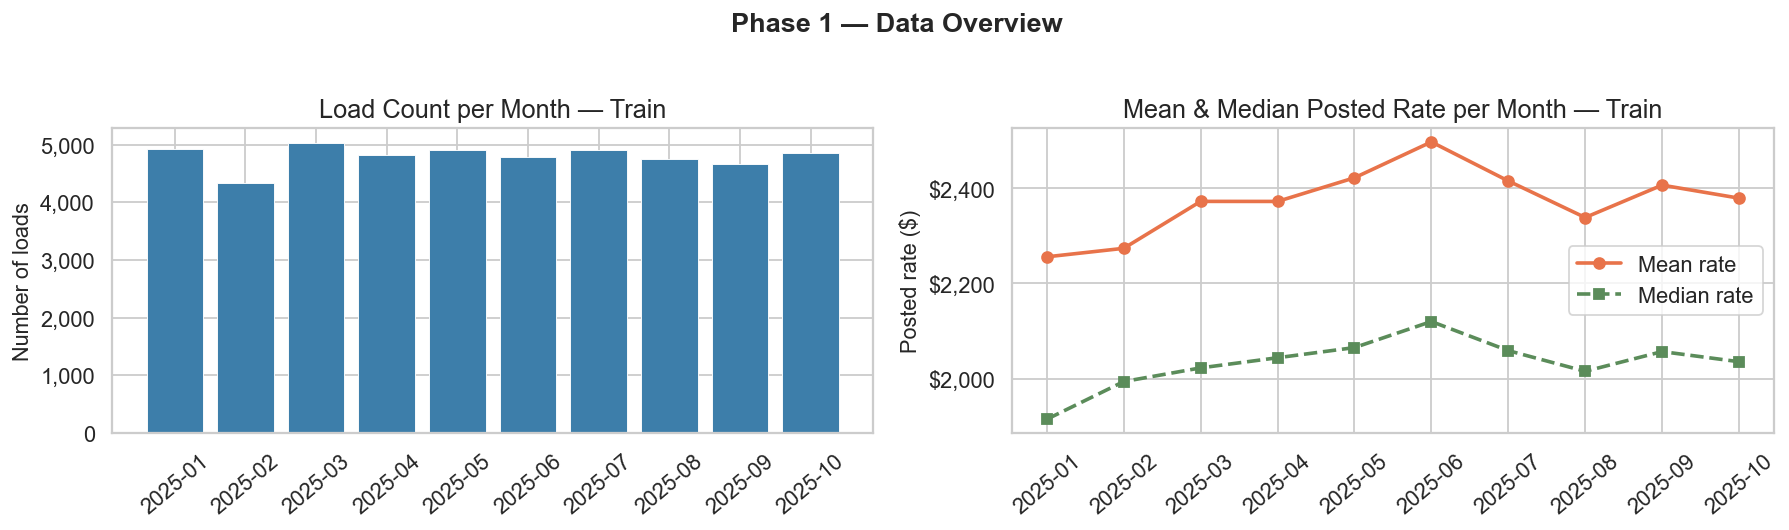

Phase 1 overview chart saved → phase1_overview.png


In [10]:
# ── Monthly load counts (train) — quick bar chart ─────────────────────────────
monthly = df_train.groupby(df_train["date"].dt.to_period("M"))["posted_rate"].agg(["count", "mean", "median"])
monthly.index = monthly.index.astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Load count per month
axes[0].bar(monthly.index, monthly["count"], color="#3D7EAA", edgecolor="white", linewidth=0.5)
axes[0].set_title("Load Count per Month — Train")
axes[0].set_ylabel("Number of loads")
axes[0].tick_params(axis="x", rotation=40)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Mean & median rate per month
axes[1].plot(monthly.index, monthly["mean"],   marker="o", label="Mean rate",   color="#E8734A", linewidth=2)
axes[1].plot(monthly.index, monthly["median"], marker="s", label="Median rate", color="#5B8C5A", linewidth=2, linestyle="--")
axes[1].set_title("Mean & Median Posted Rate per Month — Train")
axes[1].set_ylabel("Posted rate ($)")
axes[1].tick_params(axis="x", rotation=40)
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

fig.suptitle("Phase 1 — Data Overview", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("phase1_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Phase 1 overview chart saved → phase1_overview.png")

In [11]:
# ── Final Phase 1 summary ─────────────────────────────────────────────────────
print("" + "=" * 60)
print("PHASE 1 COMPLETE — Environment Setup & Data Loading")
print("=" * 60)
print(f"  Train rows      : {len(df_train):>8,}   (target: posted_rate)")
print(f"  Validation rows : {len(df_val):>8,}   (predict these)")
print(f"  December rows   : {len(df_dec):>8,}   (fixed-route chart)")
print(f"  Template rows   : {len(df_template):>8,}   (output scaffold)")
print()
print("  Key observations:")
print(f"    • Temporal gap: train ends {df_train['date'].max().date()},"
      f" val starts {df_val['date'].min().date()}")
print(f"    • Missing weight      : {df_train['weight'].isnull().sum()} train rows"
      f" / {df_val['weight'].isnull().sum()} val rows")
print(f"    • Missing market_index: {df_train['market_index'].isnull().sum()} train rows"
      f" / {df_val['market_index'].isnull().sum()} val rows")
print(f"    • Equipment types     : {sorted(df_train['equipment'].unique())}")
print(f"    • Target mean/std     : ${df_train['posted_rate'].mean():,.2f} "
      f"/ ${df_train['posted_rate'].std():,.2f}")
print()
print("  Objects available for next phases:")
print("    df_train, df_val, df_dec, df_template")
print("=" * 60)

PHASE 1 COMPLETE — Environment Setup & Data Loading
  Train rows      :   48,000   (target: posted_rate)
  Validation rows :   12,000   (predict these)
  December rows   :       31   (fixed-route chart)
  Template rows   :   12,000   (output scaffold)

  Key observations:
    • Temporal gap: train ends 2025-10-31, val starts 2025-11-01
    • Missing weight      : 300 train rows / 165 val rows
    • Missing market_index: 374 train rows / 249 val rows
    • Equipment types     : ['Dry Van', 'Flatbed', 'Reefer']
    • Target mean/std     : $2,373.98 / $1,486.49

  Objects available for next phases:
    df_train, df_val, df_dec, df_template


## Phase 2 — Exploratory Data Analysis (EDA)

### 2a — Target Distribution (`posted_rate`)

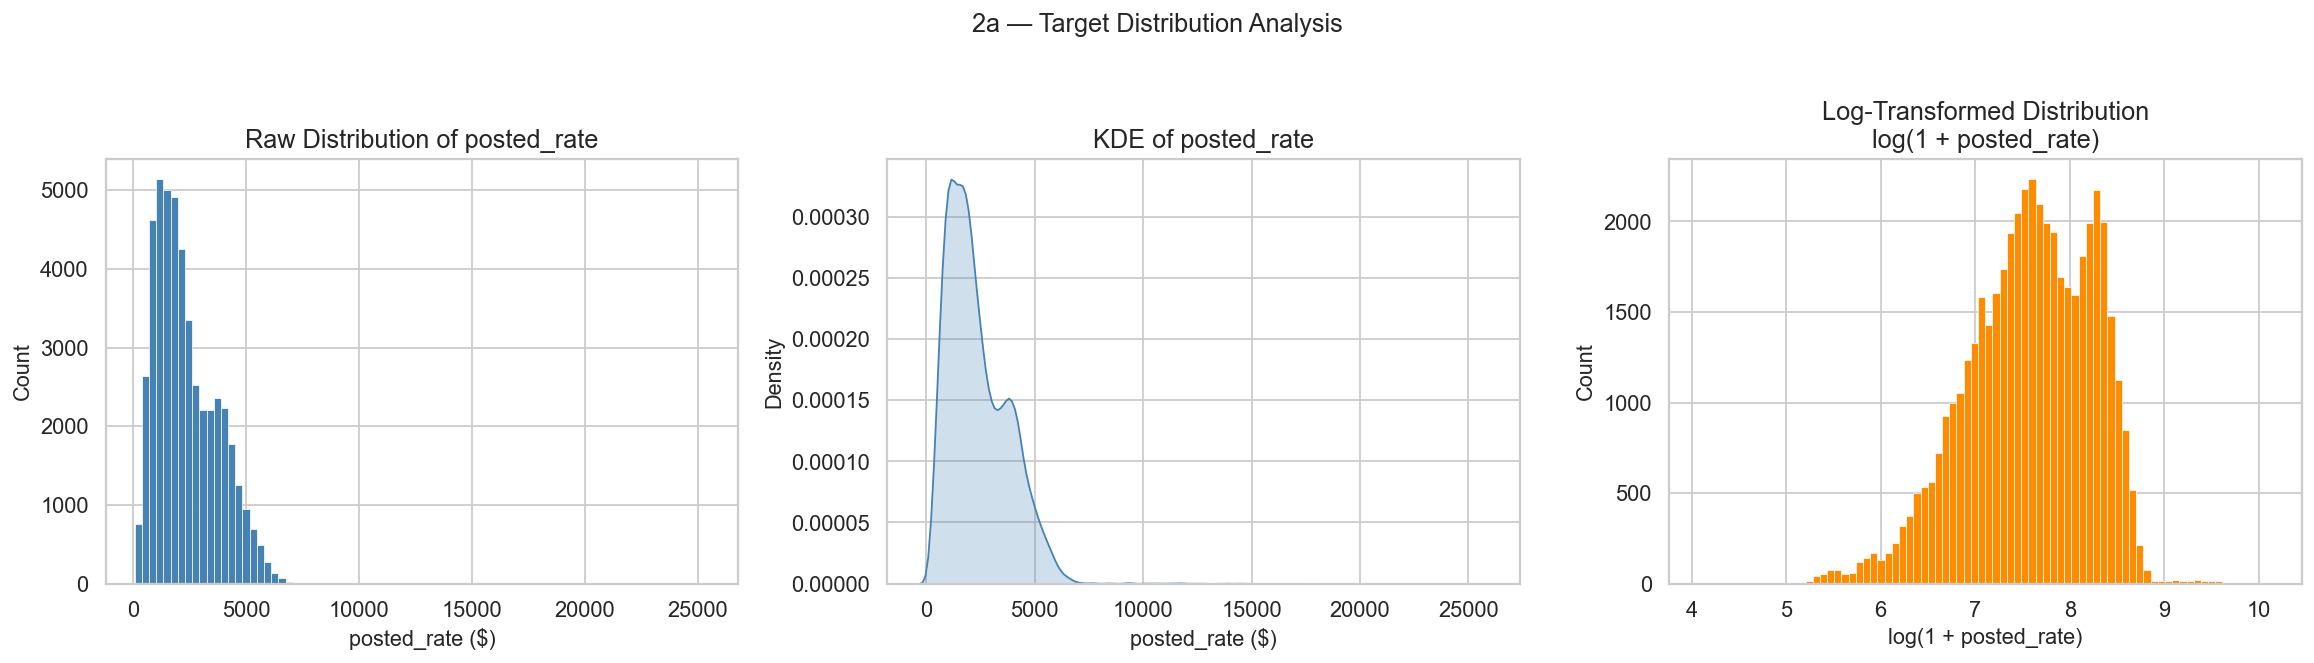

Raw skewness : 1.9024
Log skewness : -0.4889

Decision: right-skewed raw distribution → will model log(posted_rate) to reduce outlier influence.


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_train['posted_rate'], bins=80, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Raw Distribution of posted_rate')
axes[0].set_xlabel('posted_rate ($)')
axes[0].set_ylabel('Count')

sns.kdeplot(df_train['posted_rate'], ax=axes[1], fill=True, color='steelblue')
axes[1].set_title('KDE of posted_rate')
axes[1].set_xlabel('posted_rate ($)')

log_rate = np.log1p(df_train['posted_rate'])
axes[2].hist(log_rate, bins=80, color='darkorange', edgecolor='white', linewidth=0.4)
axes[2].set_title('Log-Transformed Distribution\nlog(1 + posted_rate)')
axes[2].set_xlabel('log(1 + posted_rate)')
axes[2].set_ylabel('Count')

plt.suptitle('2a — Target Distribution Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('eda_2a_target_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

skewness = df_train['posted_rate'].skew()
log_skewness = log_rate.skew()
print(f'Raw skewness : {skewness:.4f}')
print(f'Log skewness : {log_skewness:.4f}')
print()
print('Decision: right-skewed raw distribution → will model log(posted_rate) to reduce outlier influence.')


### 2b — Missing Value Analysis

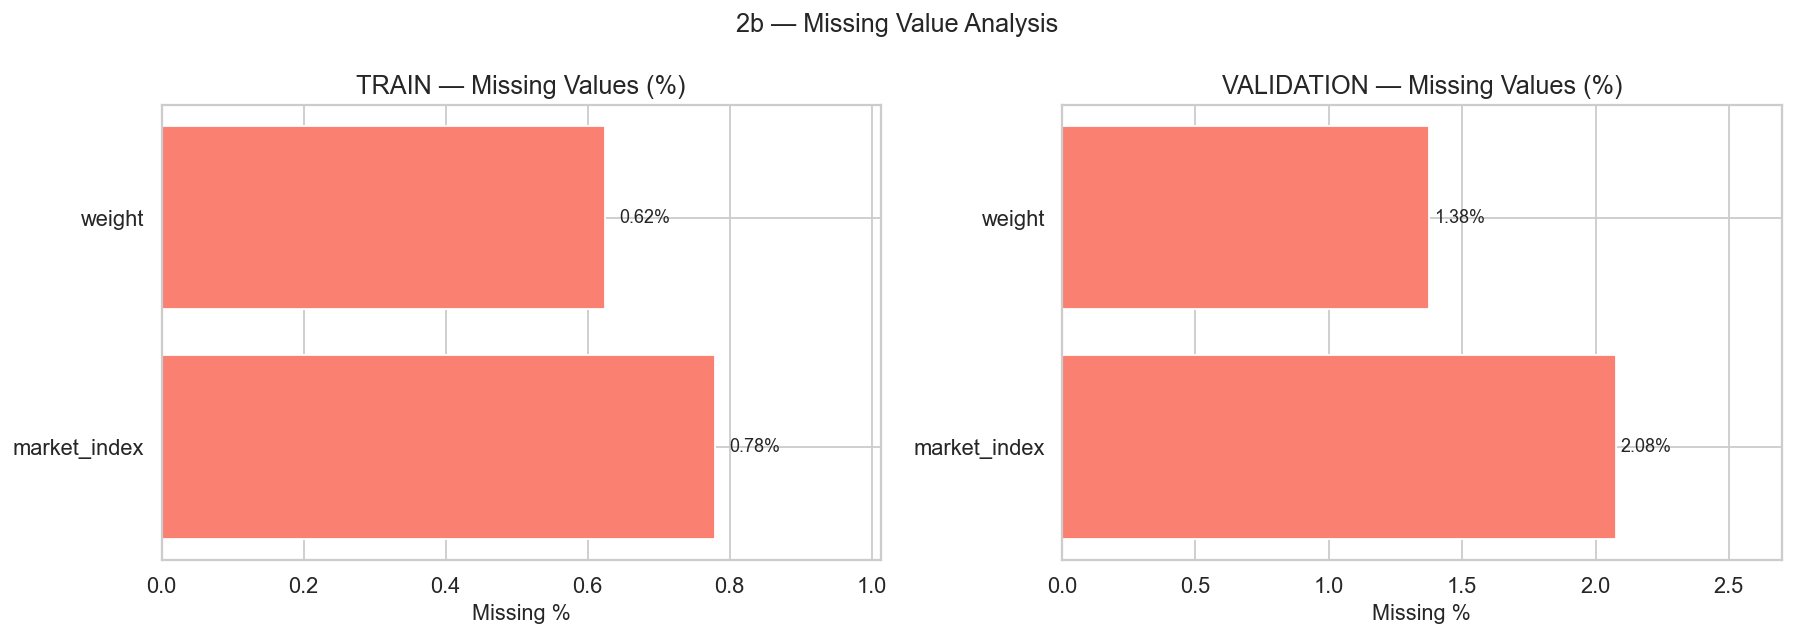

Imputation strategy:
  weight       → median per equipment type (different load types have different weight norms)
  market_index → 7-day rolling mean per date, fallback to global median


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, title) in zip(axes, [(df_train, 'TRAIN'), (df_val, 'VALIDATION')]):
    missing_pct = df.isnull().mean() * 100
    missing_df = pd.DataFrame({'column': missing_pct.index, 'missing_pct': missing_pct.values})
    missing_df = missing_df[missing_df['missing_pct'] > 0].sort_values('missing_pct', ascending=False)

    if missing_df.empty:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center', fontsize=12)
        ax.set_title(f'{title} — No Missing Values')
    else:
        bars = ax.barh(missing_df['column'], missing_df['missing_pct'], color='salmon')
        for bar, val in zip(bars, missing_df['missing_pct']):
            ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
                    f'{val:.2f}%', va='center', fontsize=10)
        ax.set_title(f'{title} — Missing Values (%)')
        ax.set_xlabel('Missing %')
        ax.set_xlim(0, max(missing_df['missing_pct']) * 1.3)

plt.suptitle('2b — Missing Value Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('eda_2b_missing_values.png', dpi=130, bbox_inches='tight')
plt.show()

print('Imputation strategy:')
print('  weight       → median per equipment type (different load types have different weight norms)')
print('  market_index → 7-day rolling mean per date, fallback to global median')


### 2c — Feature vs Target Relationships

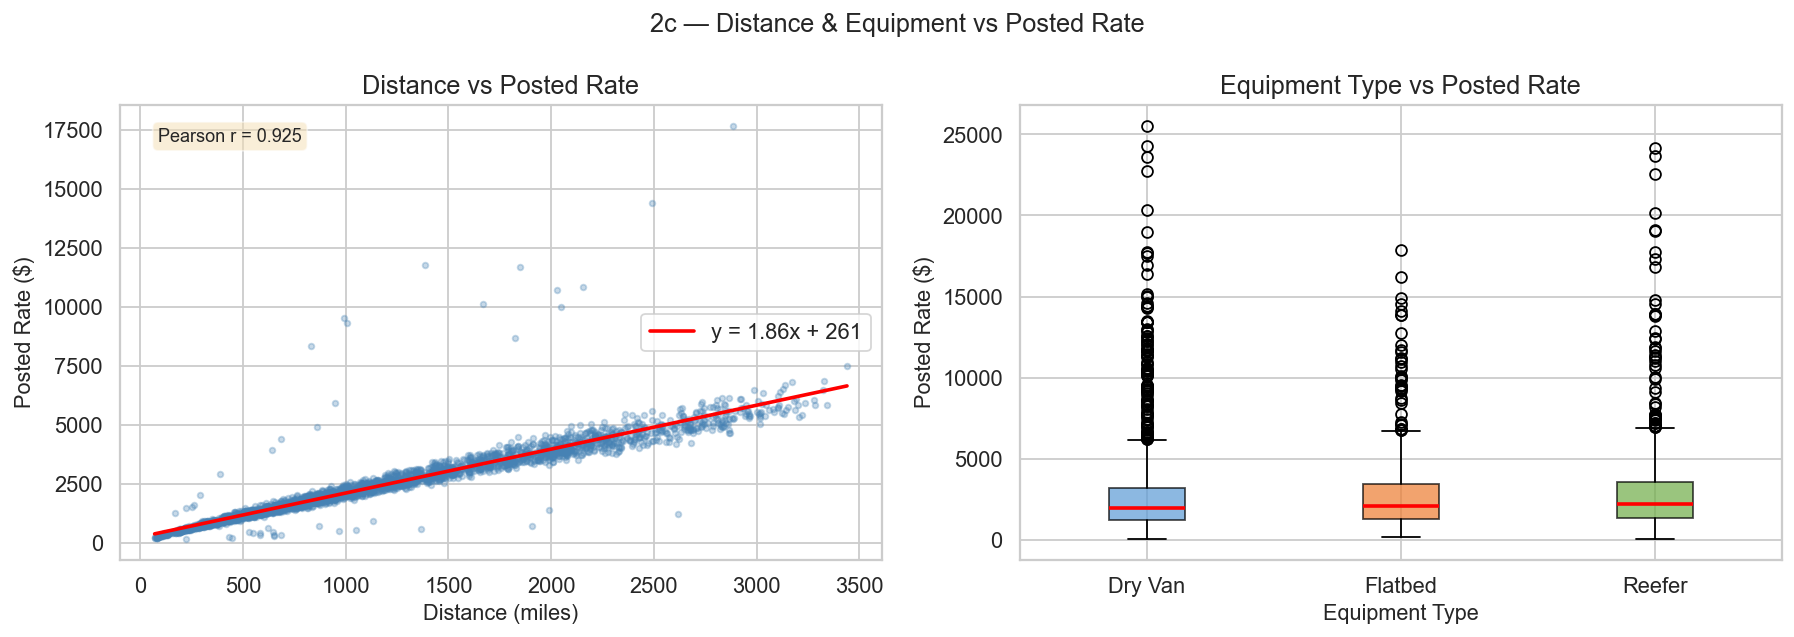

Median posted_rate by equipment:
equipment
Reefer    2196.6700
Flatbed   2076.8100
Dry Van   1953.0350


In [14]:
sample = df_train.sample(3000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(sample['distance'], sample['posted_rate'], alpha=0.3, s=10, color='steelblue')
m, b = np.polyfit(sample['distance'], sample['posted_rate'], 1)
x_line = np.linspace(sample['distance'].min(), sample['distance'].max(), 200)
axes[0].plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'y = {m:.2f}x + {b:.0f}')
axes[0].set_title('Distance vs Posted Rate')
axes[0].set_xlabel('Distance (miles)')
axes[0].set_ylabel('Posted Rate ($)')
axes[0].legend()

corr = sample[['distance', 'posted_rate']].corr().iloc[0, 1]
axes[0].text(0.05, 0.92, f'Pearson r = {corr:.3f}', transform=axes[0].transAxes,
             fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

equipment_order = ['Dry Van', 'Flatbed', 'Reefer']
groups = [df_train[df_train['equipment'] == eq]['posted_rate'].dropna() for eq in equipment_order]
bp = axes[1].boxplot(groups, labels=equipment_order, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))
colors = ['#5B9BD5', '#ED7D31', '#70AD47']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Equipment Type vs Posted Rate')
axes[1].set_xlabel('Equipment Type')
axes[1].set_ylabel('Posted Rate ($)')

plt.suptitle('2c — Distance & Equipment vs Posted Rate', fontsize=14)
plt.tight_layout()
plt.savefig('eda_2c_distance_equipment.png', dpi=130, bbox_inches='tight')
plt.show()

print('Median posted_rate by equipment:')
print(df_train.groupby('equipment')['posted_rate'].median().sort_values(ascending=False).to_string())


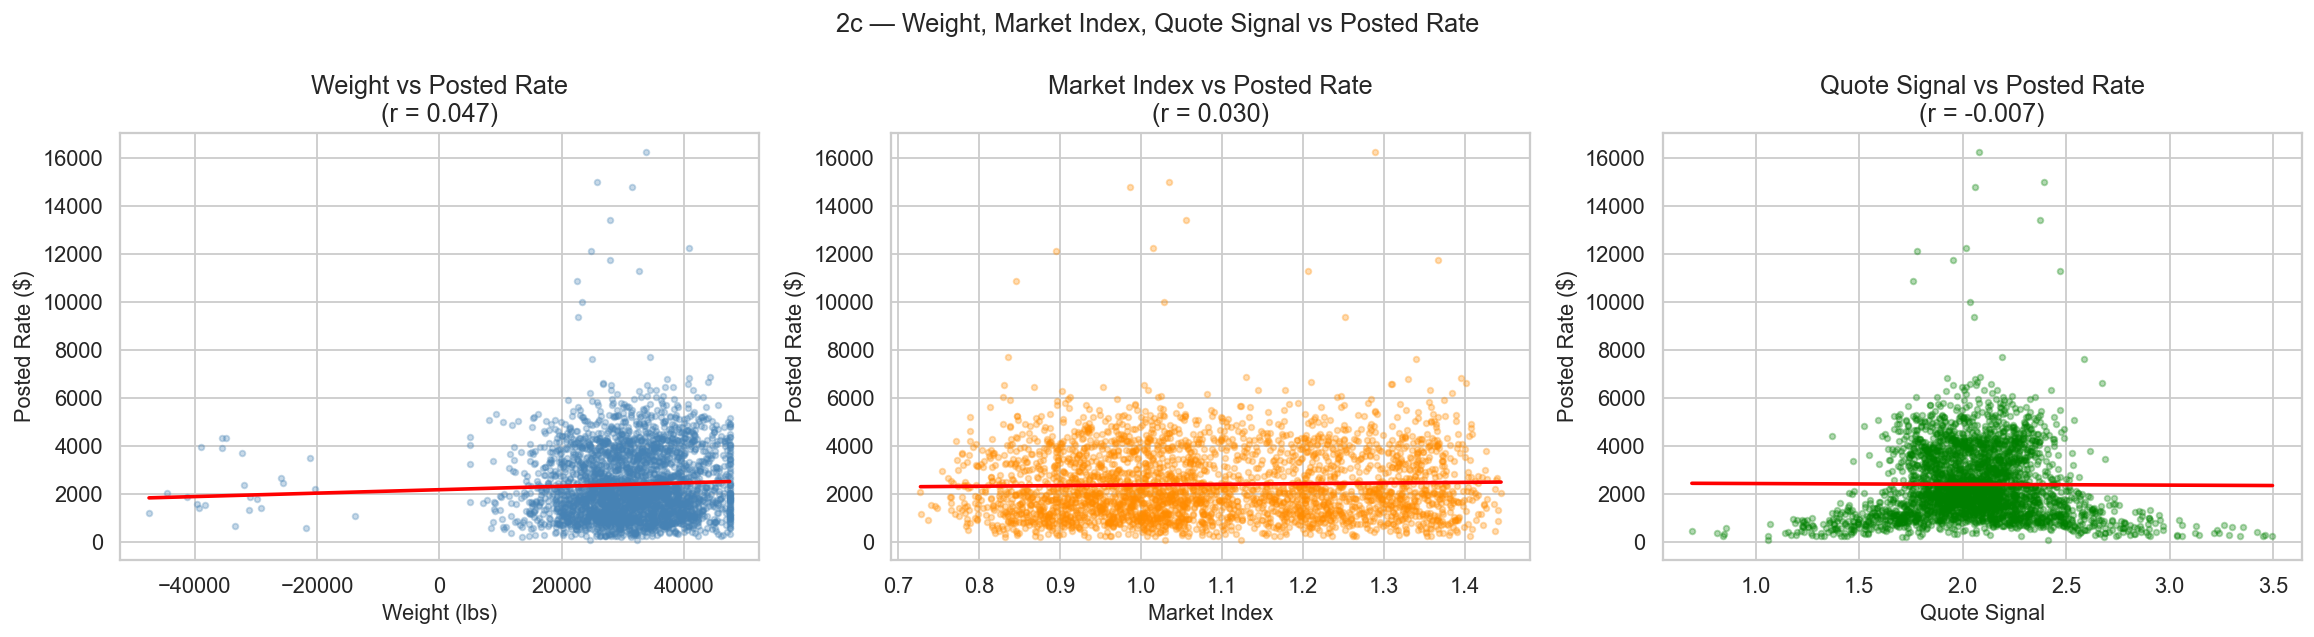

In [15]:
sample = df_train.dropna(subset=['weight', 'market_index']).sample(3000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(sample['weight'], sample['posted_rate'], alpha=0.3, s=10, color='steelblue')
m, b = np.polyfit(sample['weight'], sample['posted_rate'], 1)
x_line = np.linspace(sample['weight'].min(), sample['weight'].max(), 200)
axes[0].plot(x_line, m * x_line + b, color='red', linewidth=2)
corr = sample[['weight', 'posted_rate']].corr().iloc[0, 1]
axes[0].set_title(f'Weight vs Posted Rate\n(r = {corr:.3f})')
axes[0].set_xlabel('Weight (lbs)')
axes[0].set_ylabel('Posted Rate ($)')

axes[1].scatter(sample['market_index'], sample['posted_rate'], alpha=0.3, s=10, color='darkorange')
m, b = np.polyfit(sample['market_index'], sample['posted_rate'], 1)
x_line = np.linspace(sample['market_index'].min(), sample['market_index'].max(), 200)
axes[1].plot(x_line, m * x_line + b, color='red', linewidth=2)
corr = sample[['market_index', 'posted_rate']].corr().iloc[0, 1]
axes[1].set_title(f'Market Index vs Posted Rate\n(r = {corr:.3f})')
axes[1].set_xlabel('Market Index')
axes[1].set_ylabel('Posted Rate ($)')

axes[2].scatter(sample['quote_signal'], sample['posted_rate'], alpha=0.3, s=10, color='green')
m, b = np.polyfit(sample['quote_signal'], sample['posted_rate'], 1)
x_line = np.linspace(sample['quote_signal'].min(), sample['quote_signal'].max(), 200)
axes[2].plot(x_line, m * x_line + b, color='red', linewidth=2)
corr = sample[['quote_signal', 'posted_rate']].corr().iloc[0, 1]
axes[2].set_title(f'Quote Signal vs Posted Rate\n(r = {corr:.3f})')
axes[2].set_xlabel('Quote Signal')
axes[2].set_ylabel('Posted Rate ($)')

plt.suptitle('2c — Weight, Market Index, Quote Signal vs Posted Rate', fontsize=14)
plt.tight_layout()
plt.savefig('eda_2c_numeric_features.png', dpi=130, bbox_inches='tight')
plt.show()


### 2d — Temporal Patterns

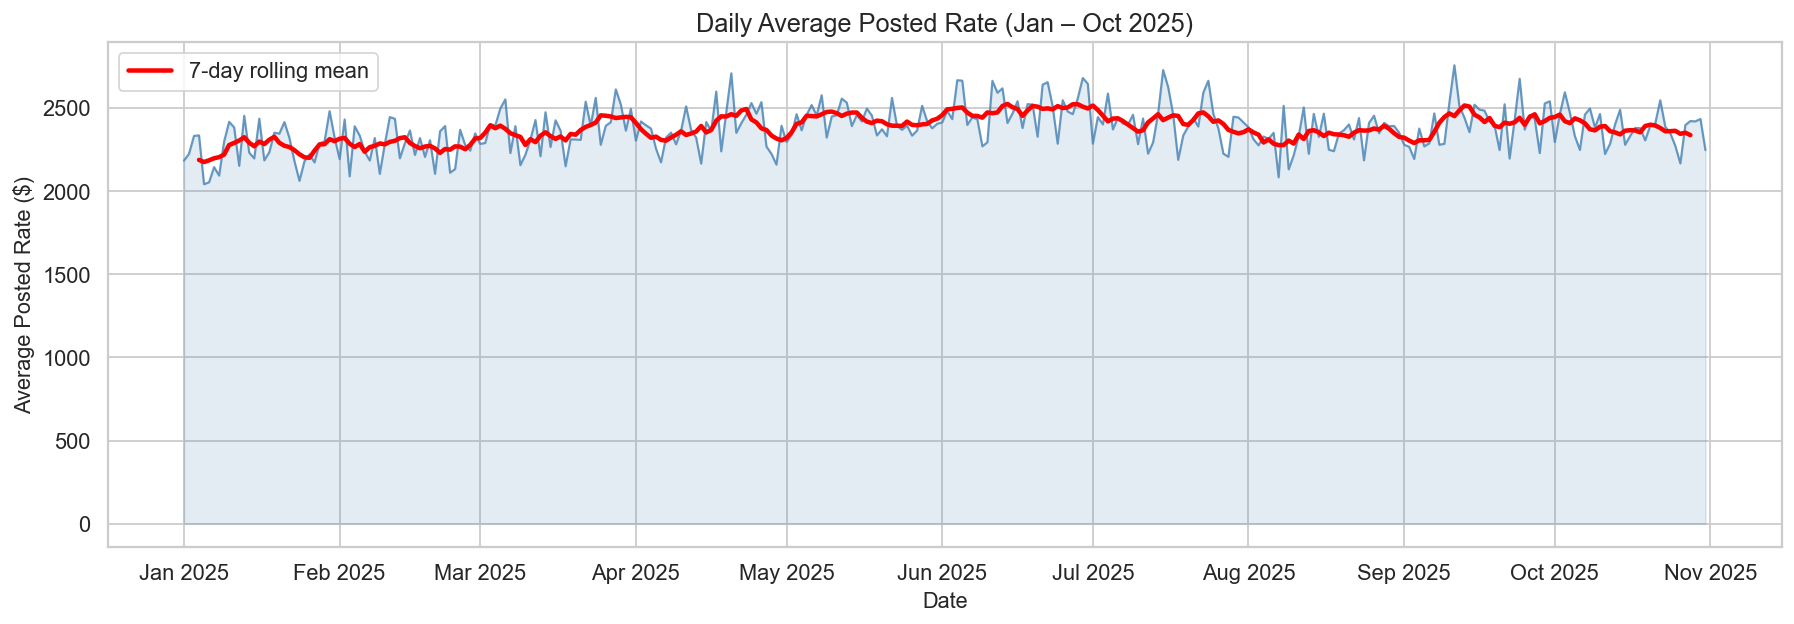

In [16]:
daily = df_train.groupby('date')['posted_rate'].mean().reset_index()
daily.columns = ['date', 'avg_rate']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily['date'], daily['avg_rate'], color='steelblue', linewidth=1.2, alpha=0.8)
ax.fill_between(daily['date'], daily['avg_rate'], alpha=0.15, color='steelblue')

rolling_7 = daily['avg_rate'].rolling(7, center=True).mean()
ax.plot(daily['date'], rolling_7, color='red', linewidth=2.5, label='7-day rolling mean')

ax.set_title('Daily Average Posted Rate (Jan – Oct 2025)')
ax.set_xlabel('Date')
ax.set_ylabel('Average Posted Rate ($)')
ax.legend()
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('eda_2d_daily_rate.png', dpi=130, bbox_inches='tight')
plt.show()


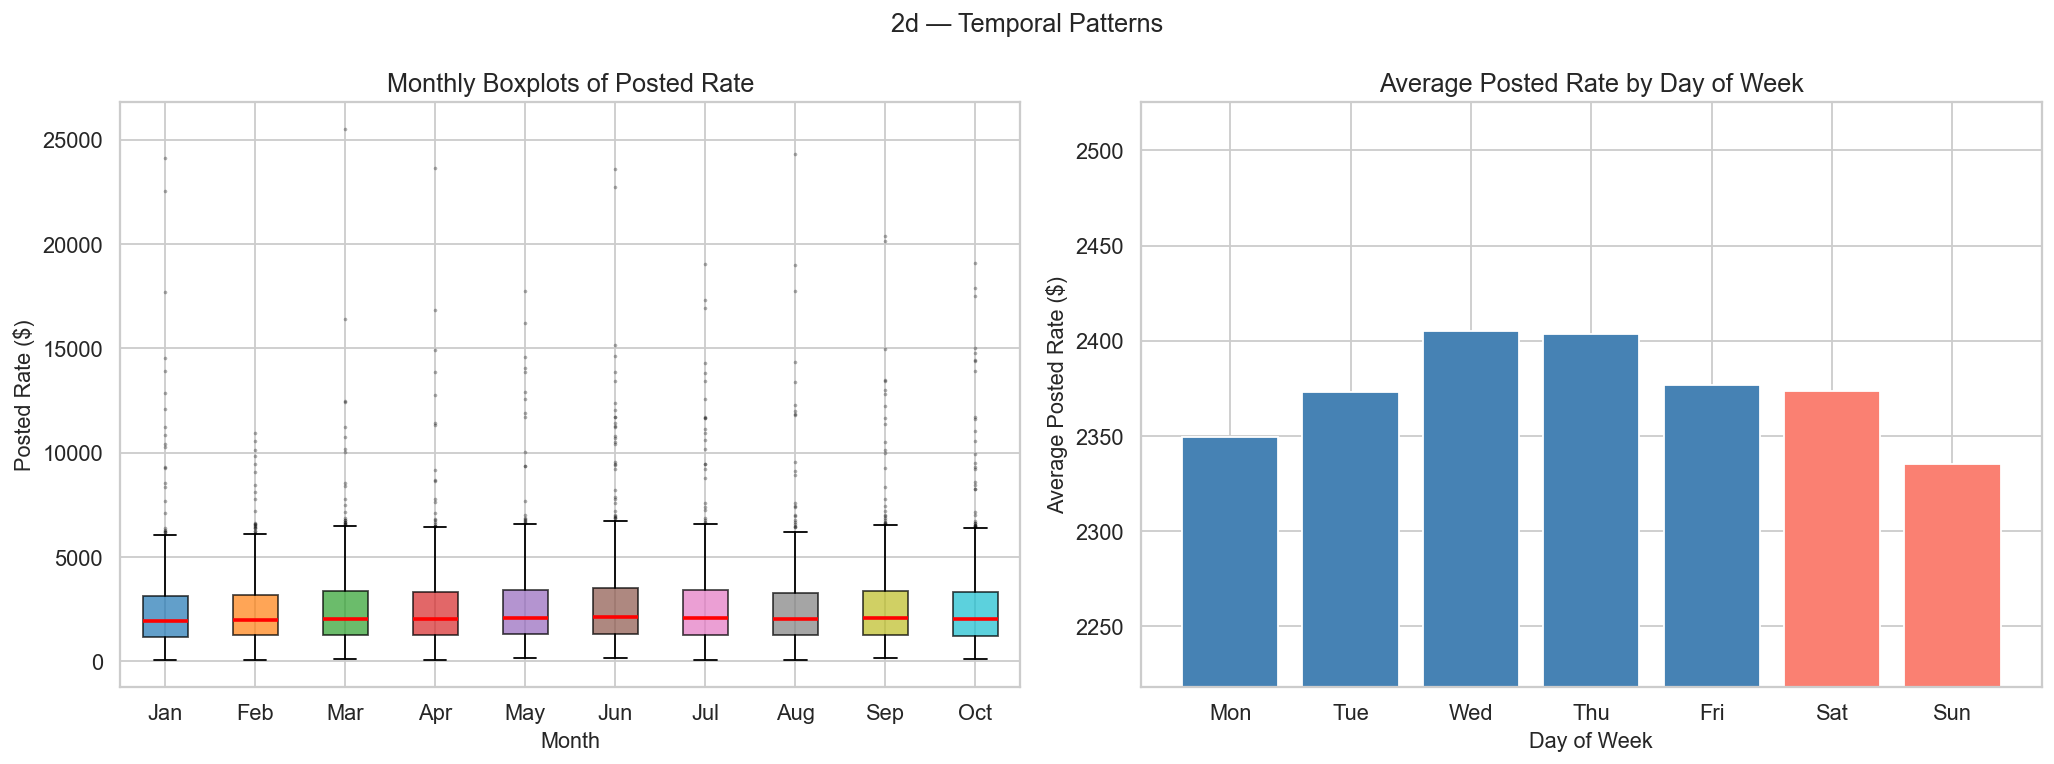

Average rate by day of week:
dow_name
Mon   2349.3087
Tue   2372.8906
Wed   2405.0867
Thu   2403.2656
Fri   2376.8499
Sat   2373.7143
Sun   2335.0732


In [17]:
df_train['month'] = df_train['date'].dt.month
df_train['month_name'] = df_train['date'].dt.strftime('%b')

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct']
df_train['month_name'] = pd.Categorical(df_train['month_name'], categories=month_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

monthly_data = [df_train[df_train['month_name'] == m]['posted_rate'].dropna() for m in month_order]
bp = axes[0].boxplot(monthly_data, labels=month_order, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2),
                     flierprops=dict(marker='.', markersize=2, alpha=0.3))
colors = plt.cm.tab10.colors
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Monthly Boxplots of Posted Rate')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Posted Rate ($)')

df_train['dow'] = df_train['date'].dt.dayofweek
df_train['dow_name'] = df_train['date'].dt.strftime('%a')
dow_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df_train['dow_name'] = pd.Categorical(df_train['dow_name'], categories=dow_order, ordered=True)

dow_means = df_train.groupby('dow_name', observed=True)['posted_rate'].mean().reindex(dow_order)
bar_colors = ['steelblue'] * 5 + ['salmon', 'salmon']
axes[1].bar(dow_order, dow_means, color=bar_colors, edgecolor='white')
axes[1].set_title('Average Posted Rate by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Posted Rate ($)')
axes[1].set_ylim(dow_means.min() * 0.95, dow_means.max() * 1.05)

plt.suptitle('2d — Temporal Patterns', fontsize=14)
plt.tight_layout()
plt.savefig('eda_2d_temporal.png', dpi=130, bbox_inches='tight')
plt.show()

print('Average rate by day of week:')
print(dow_means.to_string())


### 2e — Geographic Patterns

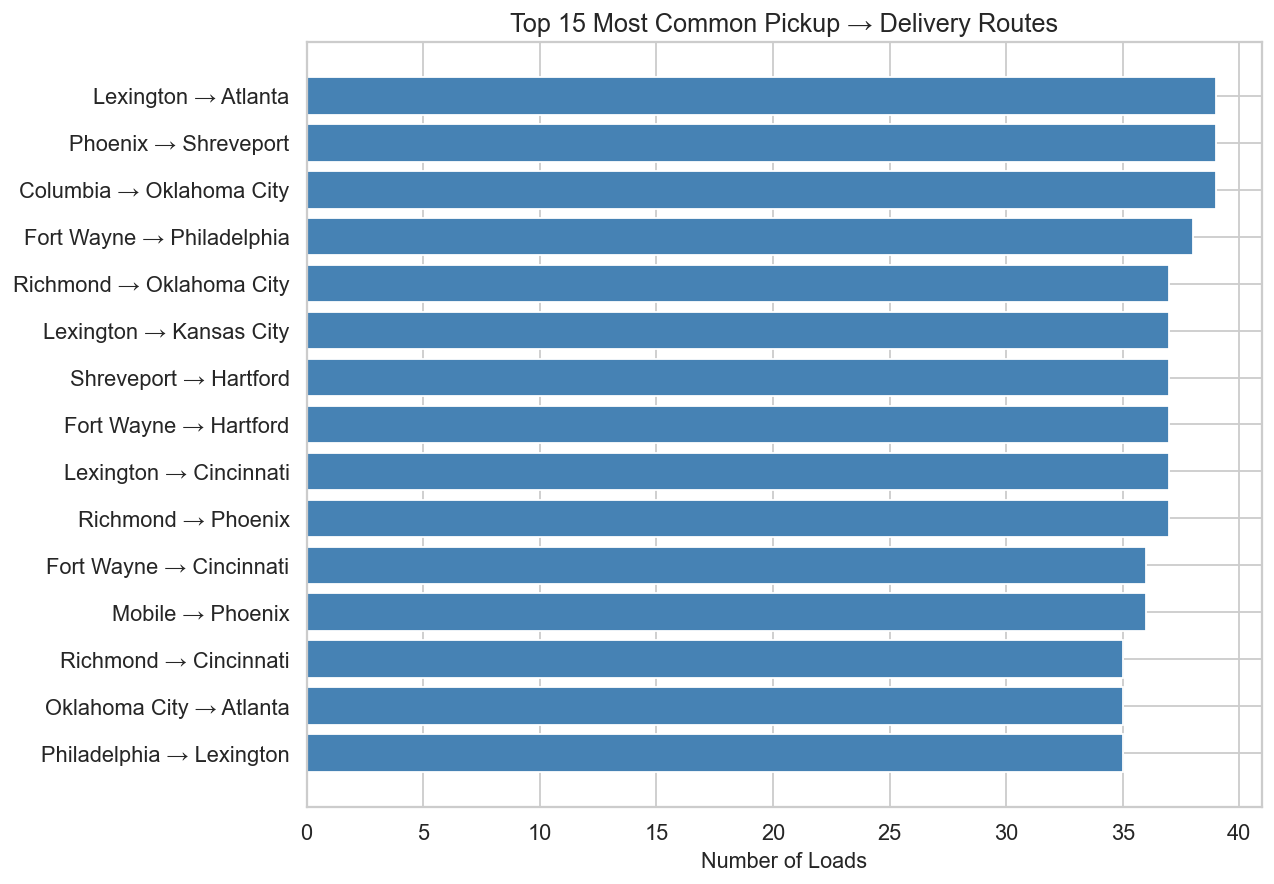

In [18]:
pair_counts = (df_train
               .groupby(['pickup', 'delivery'])
               .size()
               .reset_index(name='count')
               .sort_values('count', ascending=False)
               .head(15))

pair_counts['route'] = pair_counts['pickup'] + ' → ' + pair_counts['delivery']

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(pair_counts['route'][::-1], pair_counts['count'][::-1], color='steelblue')
ax.set_title('Top 15 Most Common Pickup → Delivery Routes')
ax.set_xlabel('Number of Loads')
plt.tight_layout()
plt.savefig('eda_2e_top_routes.png', dpi=130, bbox_inches='tight')
plt.show()


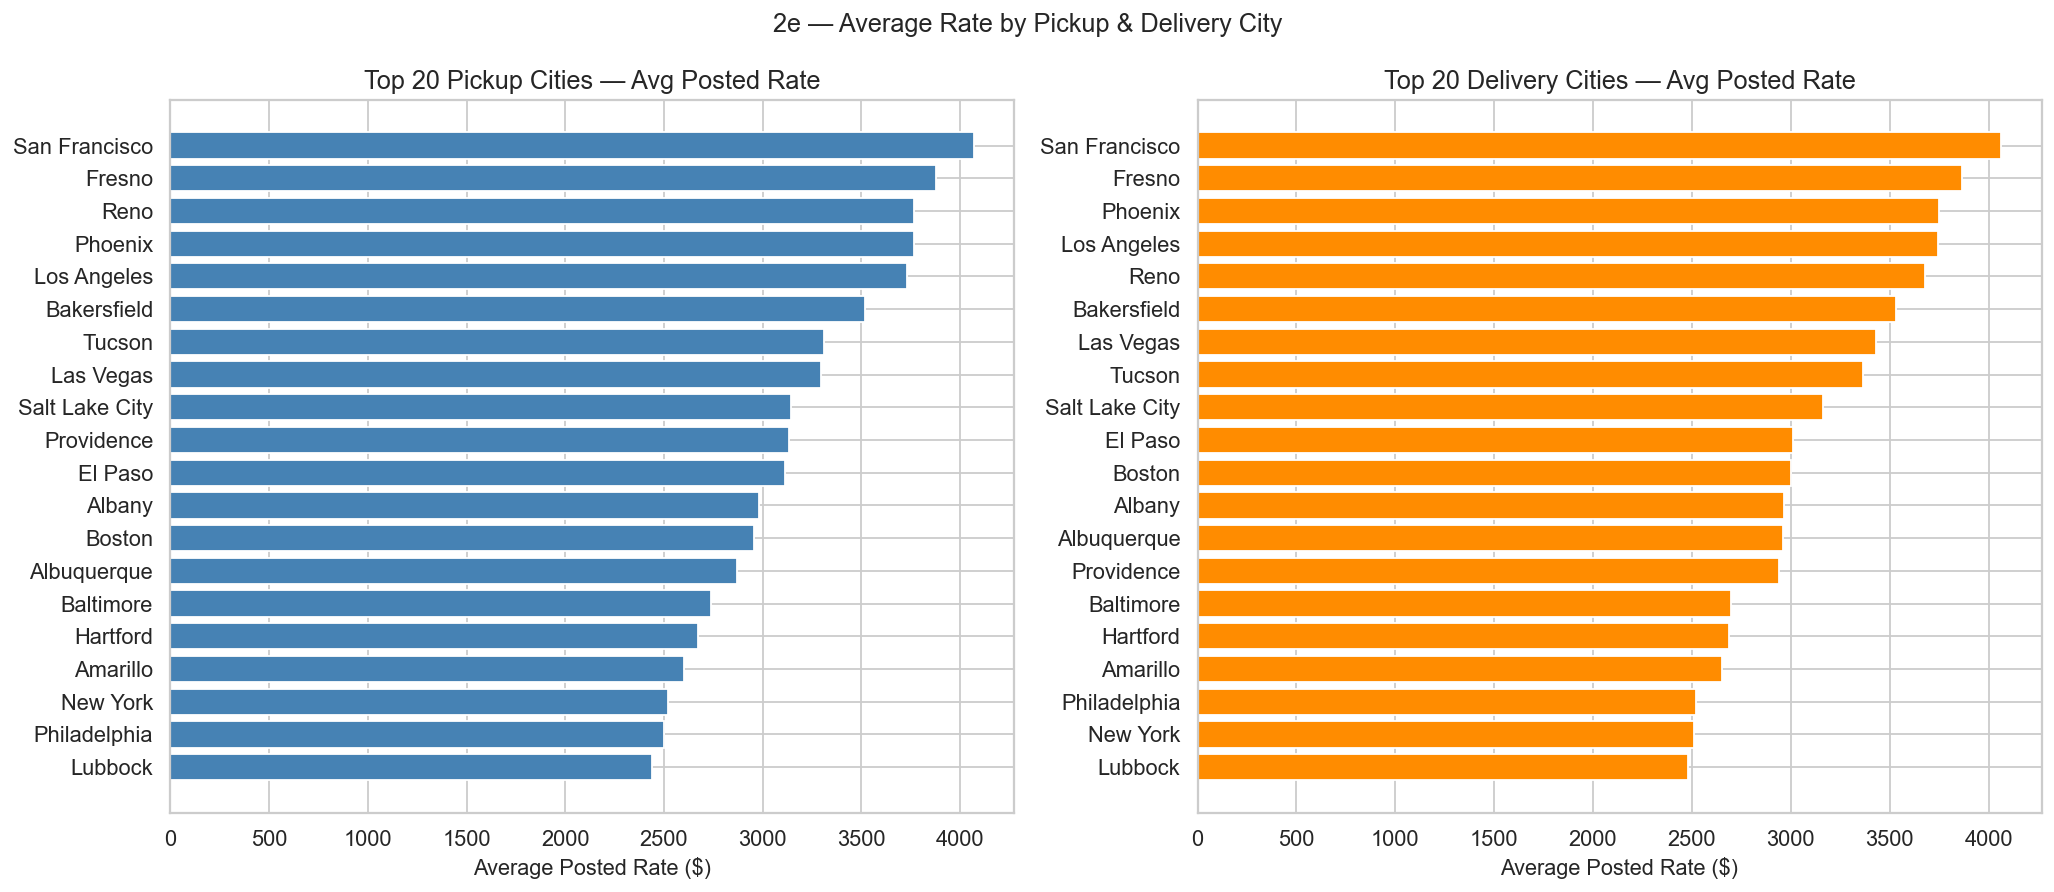

In [19]:
pivot_pickup = (df_train
                .groupby('pickup')['posted_rate']
                .mean()
                .sort_values(ascending=False)
                .head(20))

pivot_delivery = (df_train
                  .groupby('delivery')['posted_rate']
                  .mean()
                  .sort_values(ascending=False)
                  .head(20))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(pivot_pickup.index[::-1], pivot_pickup.values[::-1], color='steelblue')
axes[0].set_title('Top 20 Pickup Cities — Avg Posted Rate')
axes[0].set_xlabel('Average Posted Rate ($)')

axes[1].barh(pivot_delivery.index[::-1], pivot_delivery.values[::-1], color='darkorange')
axes[1].set_title('Top 20 Delivery Cities — Avg Posted Rate')
axes[1].set_xlabel('Average Posted Rate ($)')

plt.suptitle('2e — Average Rate by Pickup & Delivery City', fontsize=14)
plt.tight_layout()
plt.savefig('eda_2e_city_rates.png', dpi=130, bbox_inches='tight')
plt.show()


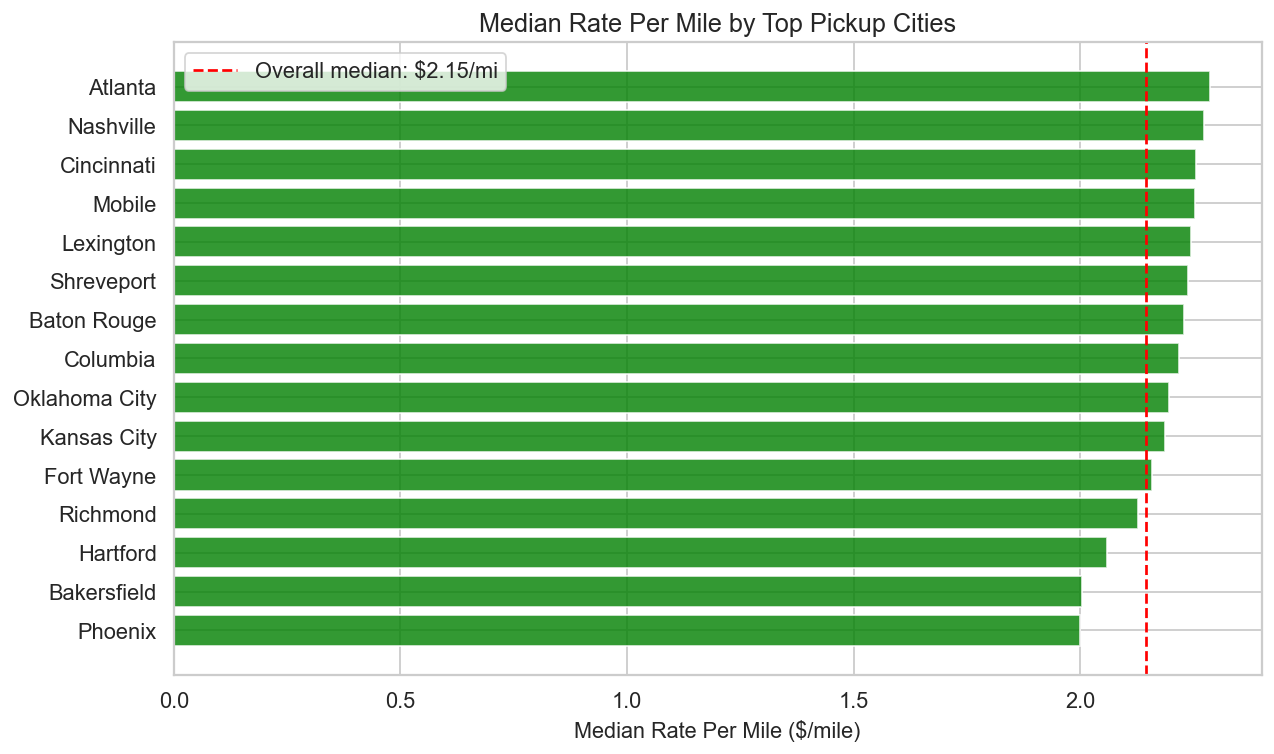

Overall median rate per mile: $2.15
Overall mean   rate per mile: $2.22


In [20]:
df_train['rate_per_mile'] = df_train['posted_rate'] / df_train['distance']

top_pickups = df_train['pickup'].value_counts().head(15).index
rate_per_mile_city = (df_train[df_train['pickup'].isin(top_pickups)]
                      .groupby('pickup')['rate_per_mile']
                      .median()
                      .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(rate_per_mile_city.index[::-1], rate_per_mile_city.values[::-1], color='green', alpha=0.8)
ax.set_title('Median Rate Per Mile by Top Pickup Cities')
ax.set_xlabel('Median Rate Per Mile ($/mile)')
ax.axvline(df_train['rate_per_mile'].median(), color='red', linestyle='--', linewidth=1.5,
           label=f'Overall median: ${df_train["rate_per_mile"].median():.2f}/mi')
ax.legend()
plt.tight_layout()
plt.savefig('eda_2e_rate_per_mile.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'Overall median rate per mile: ${df_train["rate_per_mile"].median():.2f}')
print(f'Overall mean   rate per mile: ${df_train["rate_per_mile"].mean():.2f}')


### 2f — Correlation Matrix

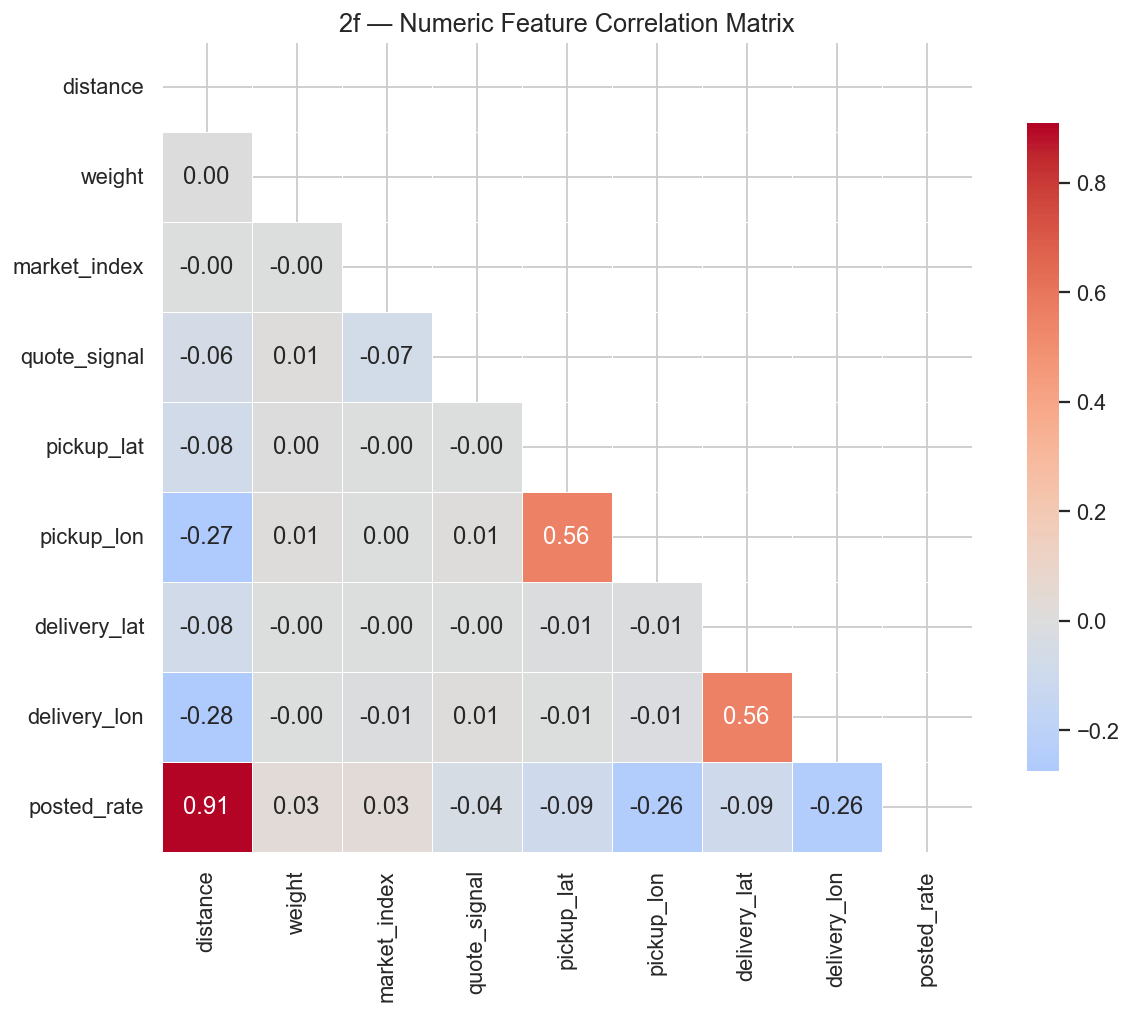

Correlations with posted_rate (sorted):
distance        0.9085
delivery_lon   -0.2571
pickup_lon     -0.2551
delivery_lat   -0.0920
pickup_lat     -0.0909
quote_signal   -0.0399
weight          0.0348
market_index    0.0342

Multicollinearity note:
  pickup_lat  / pickup_lon  — geographic pair, high internal correlation expected
  delivery_lat / delivery_lon — geographic pair, high internal correlation expected
  distance encodes the route, partially correlated with lat/lon differences


In [21]:
numeric_cols = ['distance', 'weight', 'market_index', 'quote_signal',
                'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'posted_rate']

corr_matrix = df_train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, ax=ax, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})

ax.set_title('2f — Numeric Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('eda_2f_correlation.png', dpi=130, bbox_inches='tight')
plt.show()

print('Correlations with posted_rate (sorted):')
target_corr = corr_matrix['posted_rate'].drop('posted_rate').sort_values(key=abs, ascending=False)
print(target_corr.to_string())

print()
print('Multicollinearity note:')
print('  pickup_lat  / pickup_lon  — geographic pair, high internal correlation expected')
print('  delivery_lat / delivery_lon — geographic pair, high internal correlation expected')
print('  distance encodes the route, partially correlated with lat/lon differences')


### 2g — EDA Summary & Key Findings

In [22]:
print('=' * 65)
print(' Phase 2 — EDA Key Findings')
print('=' * 65)
print()
print('2a. Target Distribution')
print(f'    Raw skewness   : {df_train["posted_rate"].skew():.3f}')
print(f'    Log skewness   : {np.log1p(df_train["posted_rate"]).skew():.3f}')
print('    Decision       : Model log(posted_rate) to reduce outlier impact')
print()
print('2b. Missing Values')
print('    weight (train) : 300 rows (0.62%)')
print('    market_index   : 374 rows (0.78%)')
print('    Impute weight  : median per equipment type')
print('    Impute index   : 7-day rolling mean, fallback to global median')
print()
print('2c. Feature vs Target')
corr_cols = ['distance', 'weight', 'market_index', 'quote_signal']
for col in corr_cols:
    r = df_train[['posted_rate', col]].dropna().corr().iloc[0, 1]
    print(f'    {col:<16}: r = {r:.3f}')
print('    Equipment ordering: Reefer > Flatbed > Dry Van (by median)')
print()
print('2d. Temporal Patterns')
dow_mean = df_train.groupby('dow_name', observed=True)['posted_rate'].mean()
peak_dow = dow_mean.idxmax()
low_dow = dow_mean.idxmin()
print(f'    Peak day-of-week  : {peak_dow} (avg ${dow_mean.max():,.0f})')
print(f'    Low  day-of-week  : {low_dow} (avg ${dow_mean.min():,.0f})')
print()
print('2e. Geographic Patterns')
print(f'    Overall median rate/mile : ${df_train["rate_per_mile"].median():.2f}')
print()
print('2f. Multicollinearity')
print('    pickup_lat ↔ pickup_lon, delivery_lat ↔ delivery_lon — correlated pairs')
print('    distance partially encodes lat/lon difference')
print('    Action: use distance + haversine features; drop raw lat/lon or use PCA')


 Phase 2 — EDA Key Findings

2a. Target Distribution
    Raw skewness   : 1.902
    Log skewness   : -0.489
    Decision       : Model log(posted_rate) to reduce outlier impact

2b. Missing Values
    weight (train) : 300 rows (0.62%)
    market_index   : 374 rows (0.78%)
    Impute weight  : median per equipment type
    Impute index   : 7-day rolling mean, fallback to global median

2c. Feature vs Target
    distance        : r = 0.909
    weight          : r = 0.035
    market_index    : r = 0.034
    quote_signal    : r = -0.040
    Equipment ordering: Reefer > Flatbed > Dry Van (by median)

2d. Temporal Patterns
    Peak day-of-week  : Wed (avg $2,405)
    Low  day-of-week  : Sun (avg $2,335)

2e. Geographic Patterns
    Overall median rate/mile : $2.15

2f. Multicollinearity
    pickup_lat ↔ pickup_lon, delivery_lat ↔ delivery_lon — correlated pairs
    distance partially encodes lat/lon difference
    Action: use distance + haversine features; drop raw lat/lon or use PCA
